<a href="https://colab.research.google.com/github/syed-sadain/Crypto-Trader-Sentiment-Analysis/blob/main/Trader_Behavior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sentiment Data:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trader Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1

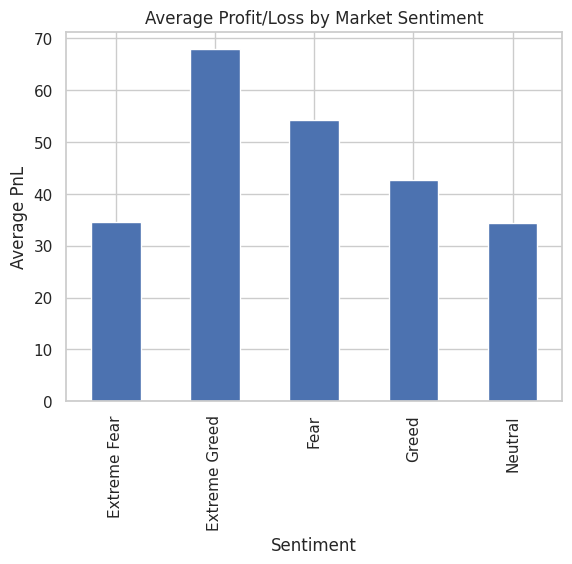

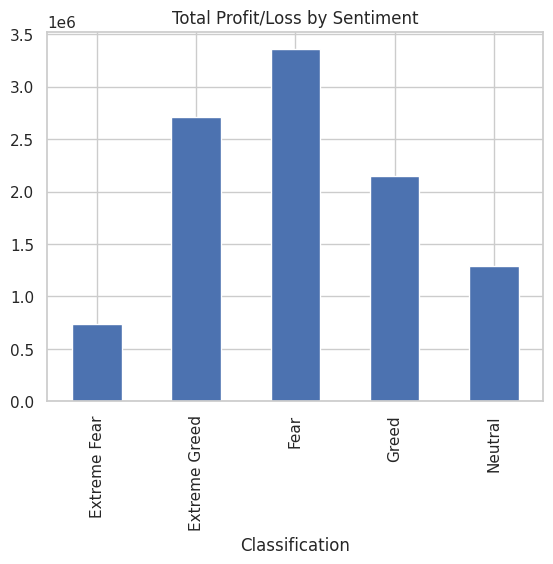

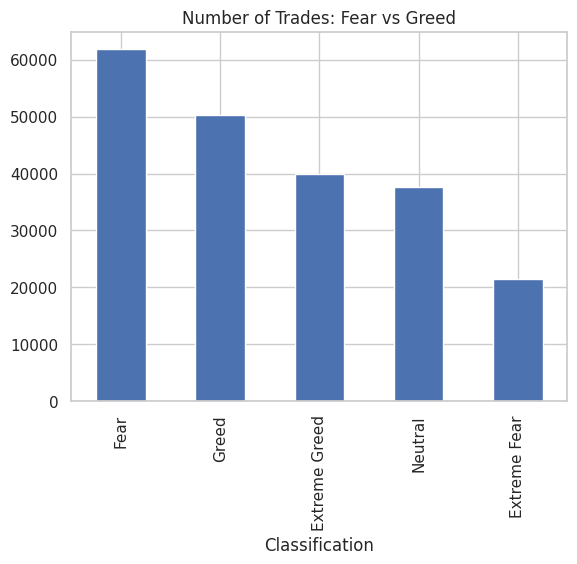

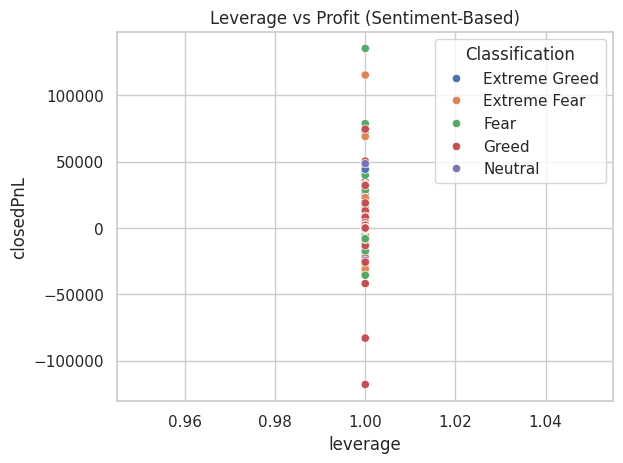

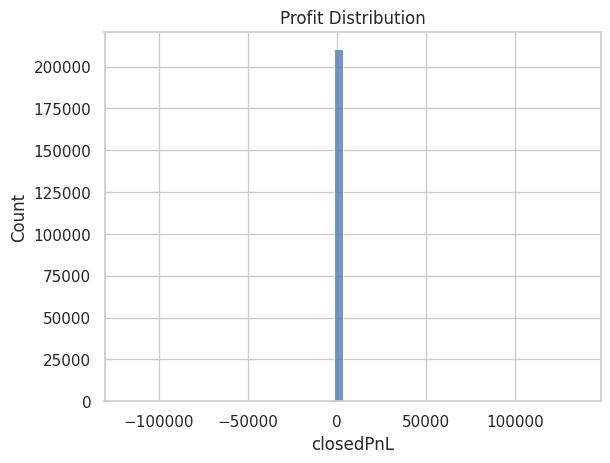

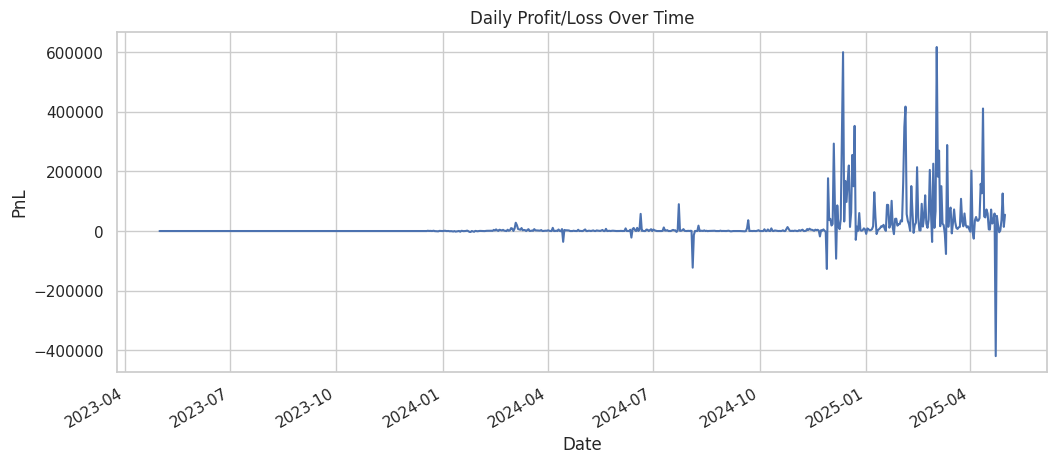

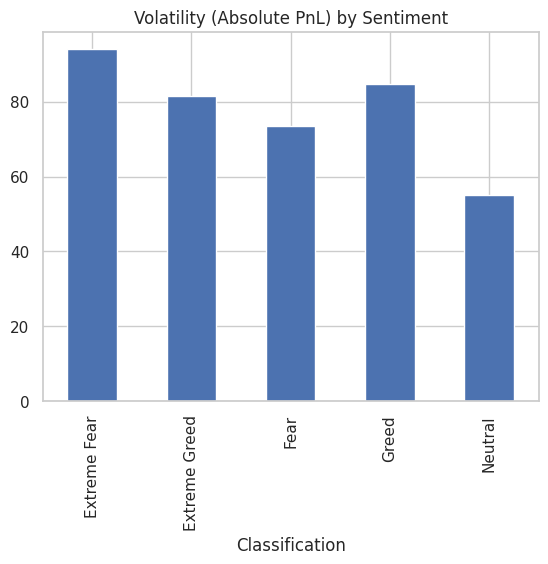

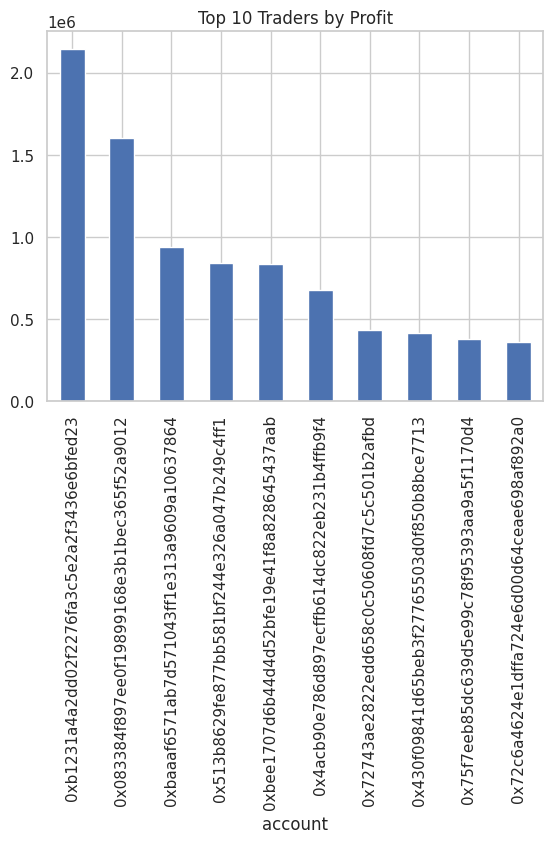


Top Traders by Win Rate:
account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0    0.573141
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0xbaaaf6571ab7d571043ff1e313a9609a10637864    0.467582
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f    0.452213
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
Name: PnL_Category, dtype: float64


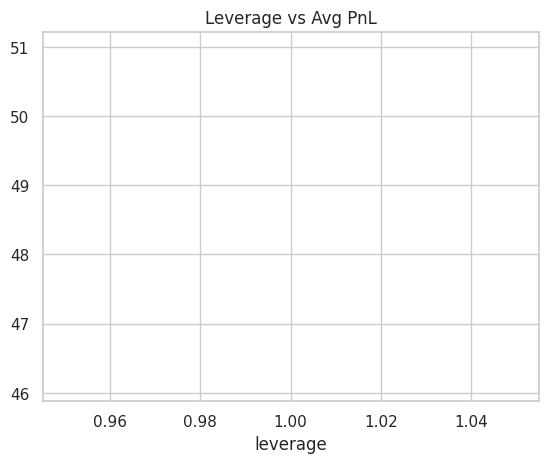


Profit Ratio:
Classification  PnL_Category
Extreme Fear    Loss            0.629393
                Profit          0.370607
Extreme Greed   Loss            0.535057
                Profit          0.464943
Fear            Loss            0.579232
                Profit          0.420768
Greed           Loss            0.615172
                Profit          0.384828
Neutral         Loss            0.603009
                Profit          0.396991
Name: proportion, dtype: float64

================ FINAL INSIGHTS ================

1.in Greed phase traders take  more risk   → high volatility and losses.
2.in Fear phase mein trading relatively stable .
3. Overtrading Greed phase is more.
4. Few traders consistently profit generate.




In [10]:
# =========================================================
# 📌 1. IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# =========================================================
# 📌 2. LOAD DATA (UPDATED FILES)
# =========================================================
sentiment = pd.read_csv("sentiment.csv")
trader = pd.read_csv("trader_data.csv")

print("Sentiment Data:")
print(sentiment.head())

print("\nTrader Data:")
print(trader.head())


# =========================================================
# 📌 3. DATA CLEANING (FIXED)
# =========================================================

# ---- Sentiment Fix ----
sentiment.rename(columns={
    'date': 'Date',
    'classification': 'Classification'
}, inplace=True)

sentiment['Date'] = pd.to_datetime(sentiment['Date'], errors='coerce')


# ---- Trader Fix ----
trader.rename(columns={
    'Timestamp IST': 'Date',
    'Closed PnL': 'closedPnL',
    'Account': 'account'
}, inplace=True)

# Convert date format
trader['Date'] = pd.to_datetime(trader['Date'], format='%d-%m-%Y %H:%M', errors='coerce')
trader['Date'] = trader['Date'].dt.date
trader['Date'] = pd.to_datetime(trader['Date'])

# Remove missing values
trader = trader.dropna(subset=['closedPnL'])

# Convert numeric
trader['closedPnL'] = pd.to_numeric(trader['closedPnL'], errors='coerce')

# Add leverage (not present in dataset)
trader['leverage'] = 1

print("\nAfter Cleaning:")
print(trader.info())


# =========================================================
# 📌 4. MERGE DATASETS
# =========================================================

merged = pd.merge(trader, sentiment, on="Date", how="inner")

print("\nMerged Data:")
print(merged.head())


# =========================================================
# 📌 5. FEATURE ENGINEERING
# =========================================================

merged['PnL_Category'] = merged['closedPnL'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

merged['absPnL'] = merged['closedPnL'].abs()


# =========================================================
# 📌 6. EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

# 1. Average Profit by Sentiment
sentiment_pnl = merged.groupby('Classification')['closedPnL'].mean()
print("\nAverage PnL by Sentiment:")
print(sentiment_pnl)

plt.figure()
sentiment_pnl.plot(kind='bar')
plt.title("Average Profit/Loss by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()


# 2. Total Profit by Sentiment
total_pnl = merged.groupby('Classification')['closedPnL'].sum()

plt.figure()
total_pnl.plot(kind='bar')
plt.title("Total Profit/Loss by Sentiment")
plt.show()


# 3. Trade Count
trade_count = merged['Classification'].value_counts()

plt.figure()
trade_count.plot(kind='bar')
plt.title("Number of Trades: Fear vs Greed")
plt.show()


# 4. Leverage vs Profit
plt.figure()
sns.scatterplot(data=merged, x='leverage', y='closedPnL', hue='Classification')
plt.title("Leverage vs Profit (Sentiment-Based)")
plt.show()


# 5. Profit Distribution
plt.figure()
sns.histplot(merged['closedPnL'], bins=50)
plt.title("Profit Distribution")
plt.show()


# 6. Daily Performance
daily_pnl = merged.groupby('Date')['closedPnL'].sum()

plt.figure(figsize=(12,5))
daily_pnl.plot()
plt.title("Daily Profit/Loss Over Time")
plt.xlabel("Date")
plt.ylabel("PnL")
plt.show()


# 7. Volatility by Sentiment
volatility = merged.groupby('Classification')['absPnL'].mean()

plt.figure()
volatility.plot(kind='bar')
plt.title("Volatility (Absolute PnL) by Sentiment")
plt.show()


# =========================================================
# 📌 7. TRADER ANALYSIS
# =========================================================

# Top 10 traders
top_traders = merged.groupby('account')['closedPnL'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_traders.plot(kind='bar')
plt.title("Top 10 Traders by Profit")
plt.show()


# Consistent traders (win rate)
win_rate = merged.groupby('account')['PnL_Category'].apply(
    lambda x: (x == 'Profit').mean()
).sort_values(ascending=False).head(10)

print("\nTop Traders by Win Rate:")
print(win_rate)


# =========================================================
# 📌 8. ADVANCED INSIGHTS
# =========================================================

leverage_impact = merged.groupby('leverage')['closedPnL'].mean()

plt.figure()
leverage_impact.plot()
plt.title("Leverage vs Avg PnL")
plt.show()


profit_ratio = merged.groupby('Classification')['PnL_Category'].value_counts(normalize=True)

print("\nProfit Ratio:")
print(profit_ratio)


# =========================================================
# 📌 9. FINAL INSIGHTS
# =========================================================

print("\n================ FINAL INSIGHTS ================\n")

print("1.in Greed phase traders take  more risk   → high volatility and losses.")
print("2.in Fear phase mein trading relatively stable .")
print("3. Overtrading Greed phase is more.")
print("4. Few traders consistently profit generate.")

print("\n================================================\n")